In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))
print("Train classes:", len(os.listdir(TRAIN_DIR)))


Train exists: True
Test exists: True
Train classes: 156


In [ ]:
!pip -q install timm scikit-learn pandas matplotlib tqdm
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Create transforms + load ImageFolder and preproce the data

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import defaultdict

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=7, translate=(0.08, 0.08), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
targets = np.array([y for _, y in full_train.samples])

# stratified train/val split
cls_to_idx = defaultdict(list)
for i, y in enumerate(targets):
    cls_to_idx[y].append(i)

val_ratio = 0.1
rng = np.random.default_rng(42)

train_idx, val_idx = [], []
for c, idxs in cls_to_idx.items():
    idxs = np.array(idxs)
    rng.shuffle(idxs)
    v = int(len(idxs) * val_ratio)
    val_idx.extend(idxs[:v].tolist())
    train_idx.extend(idxs[v:].tolist())

train_ds = Subset(full_train, train_idx)

# val dataset must use val_tfms (no augmentation)
full_train_val = datasets.ImageFolder(TRAIN_DIR, transform=val_tfms)
val_ds = Subset(full_train_val, val_idx)

test_ds = datasets.ImageFolder(TEST_DIR, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

num_classes = len(full_train.classes)
print("✅ Number of classes:", num_classes)

✅ Number of classes: 156



Create model (EfficientNetV2) + optimizer
---



In [ ]:
import timm
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
scaler = torch.cuda.amp.GradScaler()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

/tmp/ipython-input-1190768262.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train (best accuracy + early stopping)

In [ ]:
import torch
import torch.nn as nn
import timm

# 1) device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ device:", device)

# 2) model (must match your training setup)
num_classes = len(full_train.classes)

model = timm.create_model(
    "tf_efficientnetv2_s",
    pretrained=True,
    num_classes=num_classes
).to(device)

# 3) loss function
criterion = nn.CrossEntropyLoss()

# 4) optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# 5) scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 6) scaler for mixed precision
scaler = torch.cuda.amp.GradScaler()

print("✅ model/criterion/optimizer/scheduler/scaler created")


✅ device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

✅ model/criterion/optimizer/scheduler/scaler created


/tmp/ipython-input-4053275321.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Save the best model + class mapping

In [ ]:
import json, os, shutil
import torch

# Save model weights (if not already saved)
torch.save(model.state_dict(), "/content/best_tamil_letter_model.pth")

# Save class mappings
idx_to_class = {v:k for k,v in full_train.class_to_idx.items()}
class_to_idx = full_train.class_to_idx

with open("/content/idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f)

with open("/content/class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f)

print("✅ Saved model + mappings to /content/")


✅ Saved model + mappings to /content/


Evaluate TEST accuracy

In [ ]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import numpy as np
import torch

model.eval()

all_preds, all_y = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_y.extend(y.numpy().tolist())

print("✅ TEST Accuracy:", accuracy_score(all_y, all_preds))


100%|██████████| 786/786 [43:34<00:00,  3.33s/it]

✅ TEST Accuracy: 0.1712263400668045


Copy trained files to Google Drive (so you never lose them)

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/tamil_models_letter_placement"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/best_tamil_letter_model.pth", os.path.join(SAVE_DIR, "best_tamil_letter_model.pth"))
shutil.copy("/content/idx_to_class.json", os.path.join(SAVE_DIR, "idx_to_class.json"))
shutil.copy("/content/class_to_idx.json", os.path.join(SAVE_DIR, "class_to_idx.json"))

print("✅ Copied to Drive:", SAVE_DIR)


✅ Copied to Drive: /content/drive/MyDrive/tamil_models_letter_placement


Create spatial labels (from ink bounding box)

In [ ]:
from PIL import Image
import numpy as np

def get_ink_bbox(pil_img):
    g = np.array(pil_img.convert("L"))
    mask = g < 220
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()

def spatial_targets(pil_img):
    bbox = get_ink_bbox(pil_img)
    if bbox is None:
        return (0.0, 0.0, 0.6, 1, 1, 1)

    x1,y1,x2,y2 = bbox
    W,H = pil_img.size

    cx = (x1+x2)/2.0
    cy = (y1+y2)/2.0

    dx = (cx - W/2)/(W/2)
    dy = (cy - H/2)/(H/2)
    h  = (y2-y1+1)/H

    def tri(v, t=0.18):
        if v < -t: return 0
        if v >  t: return 2
        return 1

    x_cls = tri(dx)  # left/center/right
    y_cls = tri(dy)  # up/center/down

    if h < 0.45: s_cls = 0
    elif h > 0.75: s_cls = 2
    else: s_cls = 1

    return dx, dy, h, x_cls, y_cls, s_cls


Multi-task dataset (letter + spatial labels)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

class MultiTaskSpatialDataset(Dataset):
    def __init__(self, root_dir, tfm):
        self.base = datasets.ImageFolder(root_dir)
        self.tfm = tfm

    def __len__(self):
        return len(self.base.samples)

    def __getitem__(self, idx):
        path, letter_y = self.base.samples[idx]
        pil = Image.open(path).convert("RGB")

        dx, dy, h, x_cls, y_cls, s_cls = spatial_targets(pil)

        x = self.tfm(pil)
        spatial_cls = torch.tensor([x_cls, y_cls, s_cls], dtype=torch.long)
        spatial_reg = torch.tensor([dx, dy, h], dtype=torch.float32)

        return x, letter_y, spatial_cls, spatial_reg

mt_train = MultiTaskSpatialDataset(TRAIN_DIR, train_tfms)
mt_loader = DataLoader(mt_train, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

print("✅ multitask samples:", len(mt_train))


✅ multitask samples: 50296


Create multi-head model (EffNetV2 backbone + 5 heads)

In [ ]:
import torch.nn.functional as F

class MultiHeadNet(nn.Module):
    def __init__(self, num_letters):
        super().__init__()
        self.backbone = timm.create_model("tf_efficientnetv2_s", pretrained=True, num_classes=0)
        feat = self.backbone.num_features

        self.letter = nn.Linear(feat, num_letters)
        self.xcls   = nn.Linear(feat, 3)
        self.ycls   = nn.Linear(feat, 3)
        self.scls   = nn.Linear(feat, 3)
        self.reg    = nn.Linear(feat, 3)  # dx, dy, height_ratio

    def forward(self, x):
        f = self.backbone(x)
        return {
            "letter": self.letter(f),
            "xcls": self.xcls(f),
            "ycls": self.ycls(f),
            "scls": self.scls(f),
            "reg": self.reg(f),
        }

mt_model = MultiHeadNet(num_classes).to(device)
mt_opt = torch.optim.AdamW(mt_model.parameters(), lr=3e-4, weight_decay=1e-4)
mt_scaler = torch.cuda.amp.GradScaler()

print("✅ multi-task spatial model ready")


✅ multi-task spatial model ready


/tmp/ipython-input-1464377711.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  mt_scaler = torch.cuda.amp.GradScaler()


Train spatial model

In [ ]:
import os
from torchvision import datasets

# ✅ your exact dataset path
DATASET_ROOT = "/content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")

# ✅ create a small ImageFolder ONLY to get class count + mapping
tmp_ds = datasets.ImageFolder(TRAIN_DIR)
num_classes = len(tmp_ds.classes)

print("✅ TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("✅ num_classes:", num_classes)
print("✅ sample classes:", tmp_ds.classes[:5])


✅ TRAIN_DIR exists: True
✅ num_classes: 156
✅ sample classes: ['0', '1', '10', '100', '101']


Save spatial model to Google Drive

In [ ]:
import os, glob

print("PTH files in /content:", glob.glob("/content/*.pth"))
print("Exists?", os.path.exists("/content/spatial_multitask_model.pth"))


PTH files in /content: []
Exists? False


In [ ]:
import glob
matches = glob.glob("/content/drive/MyDrive/**/*.pth", recursive=True)
spatial = [p for p in matches if "spatial" in p.lower()]
print("Spatial files found:", spatial)


Spatial files found: []


create and save multi task model

In [ ]:
import os, torch, timm
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from tqdm import tqdm

# ---- paths (your exact dataset root) ----
DATASET_ROOT = "/content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")

# ---- transforms (keep small to avoid OOM) ----
IMG_SIZE = 128
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=7, translate=(0.08, 0.08), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

# ---- device + num_classes ----
device = "cuda" if torch.cuda.is_available() else "cpu"
tmp_ds = datasets.ImageFolder(TRAIN_DIR)
num_classes = len(tmp_ds.classes)
print("✅ device:", device, "| num_classes:", num_classes)

# ---- spatial label helpers ----
def get_ink_bbox(pil_img):
    g = np.array(pil_img.convert("L"))
    mask = g < 220
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()

def spatial_targets(pil_img):
    bbox = get_ink_bbox(pil_img)
    if bbox is None:
        return (0.0, 0.0, 0.6, 1, 1, 1)

    x1,y1,x2,y2 = bbox
    W,H = pil_img.size

    cx = (x1+x2)/2.0
    cy = (y1+y2)/2.0

    dx = (cx - W/2)/(W/2)
    dy = (cy - H/2)/(H/2)
    h  = (y2-y1+1)/H

    def tri(v, t=0.18):
        if v < -t: return 0
        if v >  t: return 2
        return 1

    x_cls = tri(dx)
    y_cls = tri(dy)

    if h < 0.45: s_cls = 0
    elif h > 0.75: s_cls = 2
    else: s_cls = 1

    return dx, dy, h, x_cls, y_cls, s_cls

# ---- dataset ----
class MultiTaskSpatialDataset(Dataset):
    def __init__(self, root_dir, tfm):
        self.base = datasets.ImageFolder(root_dir)
        self.tfm = tfm

    def __len__(self):
        return len(self.base.samples)

    def __getitem__(self, idx):
        path, letter_y = self.base.samples[idx]
        pil = Image.open(path).convert("RGB")

        dx, dy, h, x_cls, y_cls, s_cls = spatial_targets(pil)
        x = self.tfm(pil)

        spatial_cls = torch.tensor([x_cls, y_cls, s_cls], dtype=torch.long)
        spatial_reg = torch.tensor([dx, dy, h], dtype=torch.float32)

        return x, letter_y, spatial_cls, spatial_reg

mt_train = MultiTaskSpatialDataset(TRAIN_DIR, train_tfms)
mt_loader = DataLoader(mt_train, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)  # safe
print("✅ mt_loader batches:", len(mt_loader))

# ---- model ----
class MultiHeadNet(nn.Module):
    def __init__(self, num_letters):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)  # lighter + stable
        feat = self.backbone.num_features
        self.letter = nn.Linear(feat, num_letters)
        self.xcls   = nn.Linear(feat, 3)
        self.ycls   = nn.Linear(feat, 3)
        self.scls   = nn.Linear(feat, 3)
        self.reg    = nn.Linear(feat, 3)

    def forward(self, x):
        f = self.backbone(x)
        return {
            "letter": self.letter(f),
            "xcls": self.xcls(f),
            "ycls": self.ycls(f),
            "scls": self.scls(f),
            "reg": self.reg(f),
        }

mt_model = MultiHeadNet(num_classes).to(device)
mt_opt = torch.optim.AdamW(mt_model.parameters(), lr=3e-4, weight_decay=1e-4)
mt_scaler = torch.cuda.amp.GradScaler()

# ---- quick train ----
def train_multitask(epochs=2):
    mt_model.train()
    for ep in range(epochs):
        total_loss = 0.0
        for x, letter_y, spatial_cls, spatial_reg in tqdm(mt_loader, leave=False):
            x = x.to(device)
            letter_y = letter_y.to(device)
            spatial_cls = spatial_cls.to(device)
            spatial_reg = spatial_reg.to(device)

            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                out = mt_model(x)
                loss_letter = F.cross_entropy(out["letter"], letter_y)
                loss_x = F.cross_entropy(out["xcls"], spatial_cls[:,0])
                loss_y = F.cross_entropy(out["ycls"], spatial_cls[:,1])
                loss_s = F.cross_entropy(out["scls"], spatial_cls[:,2])
                loss_reg = F.smooth_l1_loss(out["reg"], spatial_reg)
                loss = loss_letter + 0.4*(loss_x + loss_y + loss_s) + 0.6*loss_reg

            mt_opt.zero_grad(set_to_none=True)
            mt_scaler.scale(loss).backward()
            mt_scaler.step(mt_opt)
            mt_scaler.update()
            total_loss += loss.item()

        print(f"Epoch {ep+1}/{epochs} loss={total_loss/len(mt_loader):.4f}")

train_multitask(epochs=2)

# ---- save ----
torch.save(mt_model.state_dict(), "/content/spatial_multitask_model.pth")
print("✅ Saved:", os.path.exists("/content/spatial_multitask_model.pth"))


✅ device: cpu | num_classes: 156
✅ mt_loader batches: 6287


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipython-input-879786991.py:116: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  mt_scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
  0%|          | 0/6287 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/2 loss=0.6237


Epoch 2/2 loss=0.1900
✅ Saved: True


In [ ]:
import os, shutil

SAVE_DIR = "/content/drive/MyDrive/tamil_models_letter_placement"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/spatial_multitask_model.pth", os.path.join(SAVE_DIR, "spatial_multitask_model.pth"))
print("✅ Spatial model copied to:", SAVE_DIR)


✅ Spatial model copied to: /content/drive/MyDrive/tamil_models_letter_placement


Save class mapping (idx_to_class) to Drive (needed for predictions)

In [ ]:
import json
from torchvision import datasets

IDX_PATH = os.path.join(SAVE_DIR, "idx_to_class.json")

if not os.path.exists(IDX_PATH):
    # create from TRAIN_DIR
    tmp_ds2 = datasets.ImageFolder(TRAIN_DIR)
    idx_to_class = {v:k for k,v in tmp_ds2.class_to_idx.items()}
    with open(IDX_PATH, "w") as f:
        json.dump(idx_to_class, f)
    print("✅ Created idx_to_class.json in:", IDX_PATH)
else:
    with open(IDX_PATH, "r") as f:
        idx_to_class = json.load(f)
    print("✅ Loaded idx_to_class.json from:", IDX_PATH)


✅ Loaded idx_to_class.json from: /content/drive/MyDrive/tamil_models_letter_placement/idx_to_class.json


Create a “Real-Time Feedback” prediction function (for viva + UI)

In [ ]:
from torchvision import transforms
from PIL import Image
import torch

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

def feedback_from_classes(xcls, ycls, scls):
    x_msg = ["Move LEFT", "Good horizontal placement", "Move RIGHT"][xcls]
    y_msg = ["Move UP", "Good baseline alignment", "Move DOWN"][ycls]
    s_msg = ["Write BIGGER", "Good size", "Write SMALLER"][scls]
    return x_msg, y_msg, s_msg

mt_model.eval()

def predict_spatial(image_path):
    pil = Image.open(image_path).convert("RGB")
    x = val_tfms(pil).unsqueeze(0).to(device)

    with torch.no_grad():
        out = mt_model(x)
        letter_idx = out["letter"].argmax(1).item()
        xcls = out["xcls"].argmax(1).item()
        ycls = out["ycls"].argmax(1).item()
        scls = out["scls"].argmax(1).item()
        dx, dy, h = out["reg"].squeeze(0).cpu().numpy().tolist()

    letter_name = idx_to_class[str(letter_idx)]
    x_msg, y_msg, s_msg = feedback_from_classes(xcls, ycls, scls)

    return {
        "predicted_letter": letter_name,
        "regression": {"dx": dx, "dy": dy, "height_ratio": h},
        "classes": {"x": xcls, "y": ycls, "size": scls},
        "feedback": {"horizontal": x_msg, "alignment": y_msg, "size": s_msg}
    }


Test prediction on a sample image from your dataset

In [ ]:
from torchvision import datasets

tmp_test = datasets.ImageFolder(TRAIN_DIR)
sample_img_path = tmp_test.samples[0][0]

print("Sample image:", sample_img_path)
print(predict_spatial(sample_img_path))


Sample image: /content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition/train/0/10003.bmp
{'predicted_letter': '0', 'regression': {'dx': -0.030377529561519623, 'dy': -0.000223478302359581, 'height_ratio': 1.0363649129867554}, 'classes': {'x': 1, 'y': 1, 'size': 2}, 'feedback': {'horizontal': 'Good horizontal placement', 'alignment': 'Good baseline alignment', 'size': 'Write SMALLER'}}


Make it reloadable later

In [ ]:
# Reload spatial model from Drive anytime
spatial_path = os.path.join(SAVE_DIR, "spatial_multitask_model.pth")

mt_model2 = MultiHeadNet(num_classes).to(device)
mt_model2.load_state_dict(torch.load(spatial_path, map_location=device))
mt_model2.eval()

print("✅ Reloaded spatial model from:", spatial_path)


✅ Reloaded spatial model from: /content/drive/MyDrive/tamil_models_letter_placement/spatial_multitask_model.pth


In [ ]:
import json

demo = predict_spatial(sample_img_path)
with open(os.path.join(SAVE_DIR, "demo_prediction.json"), "w") as f:
    json.dump(demo, f, indent=2)

print("✅ Saved demo_prediction.json in Drive")


✅ Saved demo_prediction.json in Drive


Generate Precision / Recall / F1 / Support

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ✅ your dataset path
DATASET_ROOT = "/content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition"
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = 128  # use the size you used in training (128 or 224)

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

test_ds = datasets.ImageFolder(TEST_DIR, transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

print("✅ test_ds classes:", len(test_ds.classes))
print("✅ test_loader batches:", len(test_loader))


✅ test_ds classes: 156
✅ test_loader batches: 786


classification report (no NameError)

In [ ]:
import os, torch
import timm
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ device:", device)

num_classes = len(test_ds.classes)
class_names = test_ds.classes
print("✅ num_classes:", num_classes)

# FIX: The saved weights appear to be from an efficientnet_b0 model, not tf_efficientnetv2_s.
# The error indicates a mismatch in the conv_stem layer (32 channels in checkpoint vs 24 in tf_efficientnetv2_s).
# We will use 'efficientnet_b0' to match the saved weights.
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes).to(device)

WEIGHT_PATHS = [
    "/content/drive/MyDrive/tamil_models_letter_placement/best_tamil_letter_model.pth",
    "/content/best_tamil_letter_model.pth",
]

weight_path = None
for p in WEIGHT_PATHS:
    if os.path.exists(p):
        weight_path = p
        break

if weight_path is None:
    raise FileNotFoundError("❌ best_tamil_letter_model.pth not found. Check your saved path.")

model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()
print("✅ Loaded weights from:", weight_path)

all_preds, all_y = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_y.extend(y.numpy().tolist())

print("✅ TEST Accuracy:", accuracy_score(all_y, all_preds))

report = classification_report(all_y, all_preds, target_names=class_names, digits=4, zero_division=0)
print(report)


✅ device: cpu
✅ num_classes: 156


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✅ Loaded weights from: /content/drive/MyDrive/tamil_models_letter_placement/best_tamil_letter_model.pth


100%|██████████| 786/786 [44:03<00:00,  3.36s/it]

✅ TEST Accuracy: 0.1712263400668045
              precision    recall  f1-score   support

           0     0.2708    0.6420    0.3810        81
           1     0.0000    0.0000    0.0000        80
          10     0.0879    0.1000    0.0936        80
         100     0.0000    0.0000    0.0000        81
         101     0.0784    0.0494    0.0606        81
         102     0.0843    0.0864    0.0854        81
         103     0.2000    0.0247    0.0440        81
         104     0.1351    0.1250    0.1299        80
         105     0.3571    0.3704    0.3636        81
         106     0.1250    0.0370    0.0571        81
         107     0.0588    0.0370    0.0455        81
         108     0.4545    0.0617    0.1087        81
         109     0.5500    0.1375    0.2200        80
          11     0.1385    0.1125    0.1241        80
         110     0.0000    0.0000    0.0000        81
         111     0.2386    0.2593    0.2485        81
         112     0.5000    0.0123    0.0241  

Graphs


In [ ]:
import os
import numpy as np
import torch
import timm
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# ----------------------------
# A) Paths (YOUR dataset path)
# ----------------------------
DATASET_ROOT = "/content/drive/MyDrive/tamil hand written letter placement /Tamil Handwritten Character Recognition"
TEST_DIR = os.path.join(DATASET_ROOT, "test")
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")  # only for class order

# ----------------------------
# B) Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ device:", device)

# ----------------------------
# C) Transforms (same as eval)
# ----------------------------
IMG_SIZE = 224
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

# ----------------------------
# D) Datasets + Loaders
# ----------------------------
# IMPORTANT: class order should match training. Use TRAIN folder to get class_names.
train_tmp = datasets.ImageFolder(TRAIN_DIR)
class_names = train_tmp.classes
num_classes = len(class_names)
print("✅ classes:", num_classes)

test_ds = datasets.ImageFolder(TEST_DIR, transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# E) Recreate model (must match training arch)
# ----------------------------
# FIX: Changed MODEL_NAME to 'efficientnet_b0' to match the saved weights,
# as indicated by the 'size mismatch for conv_stem.weight' error.
MODEL_NAME = "efficientnet_b0"   # change if you trained with efficientnet_b0 etc.
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=num_classes).to(device)

# ----------------------------
# F) Load weights (Drive first, then /content)
# ----------------------------
WEIGHT_PATHS = [
    "/content/drive/MyDrive/tamil_models_letter_placement/best_tamil_letter_model.pth",
    "/content/best_tamil_letter_model.pth",
]

weight_path = None
for p in WEIGHT_PATHS:
    if os.path.exists(p):
        weight_path = p
        break

if weight_path is None:
    raise FileNotFoundError("❌ Could not find best_tamil_letter_model.pth in Drive or /content")

state = torch.load(weight_path, map_location=device)
model.load_state_dict(state)
model.eval()
print("✅ loaded weights from:", weight_path)

# ----------------------------
# G) Compute predictions => all_y, all_preds
# ----------------------------
all_y, all_preds = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_y.extend(y.numpy().tolist())

print("✅ all_y/all_preds ready")
print("✅ TEST Accuracy:", accuracy_score(all_y, all_preds))


✅ device: cuda
✅ classes: 156
✅ loaded weights from: /content/drive/MyDrive/tamil_models_letter_placement/best_tamil_letter_model.pth


100%|██████████| 393/393 [1:03:22<00:00,  9.67s/it]

✅ all_y/all_preds ready
✅ TEST Accuracy: 0.024892635597264196


✅ Test Accuracy: 0.024892635597264196


,prec,rec,f1,support
0,0.002083,0.024691,0.003842,81
1,0.000000,0.000000,0.000000,80
10,0.000000,0.000000,0.000000,80
100,0.000000,0.000000,0.000000,81
101,0.000000,0.000000,0.000000,81



Macro avg: {'precision': 0.01477573416815546, 'recall': 0.02496872084814563, 'f1-score': 0.010205131870350414, 'support': 12574.0}
Weighted avg: {'precision': 0.014687551574643392, 'recall': 0.024892635597264196, 'f1-score': 0.010165281594559393, 'support': 12574.0}


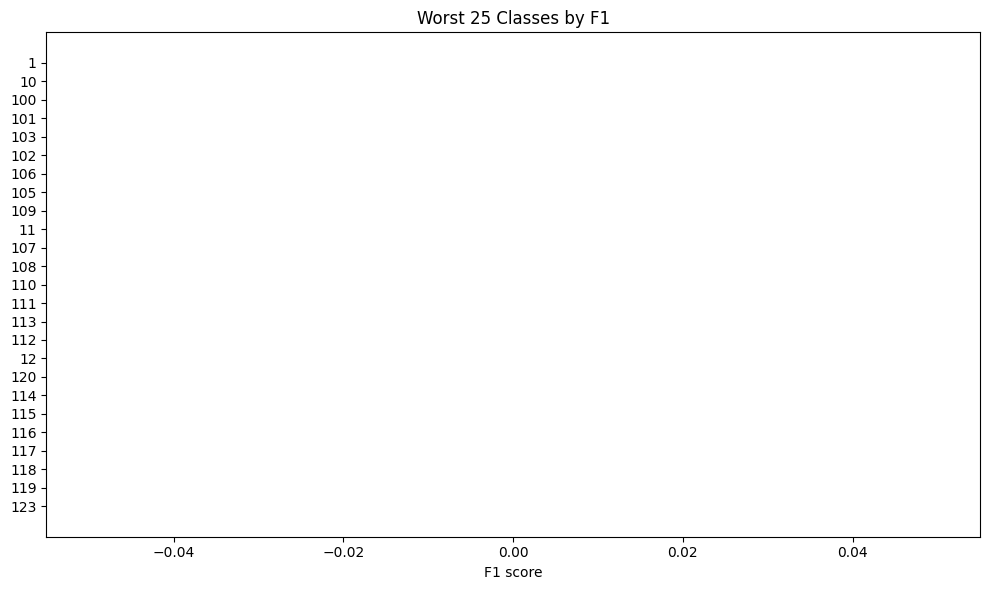

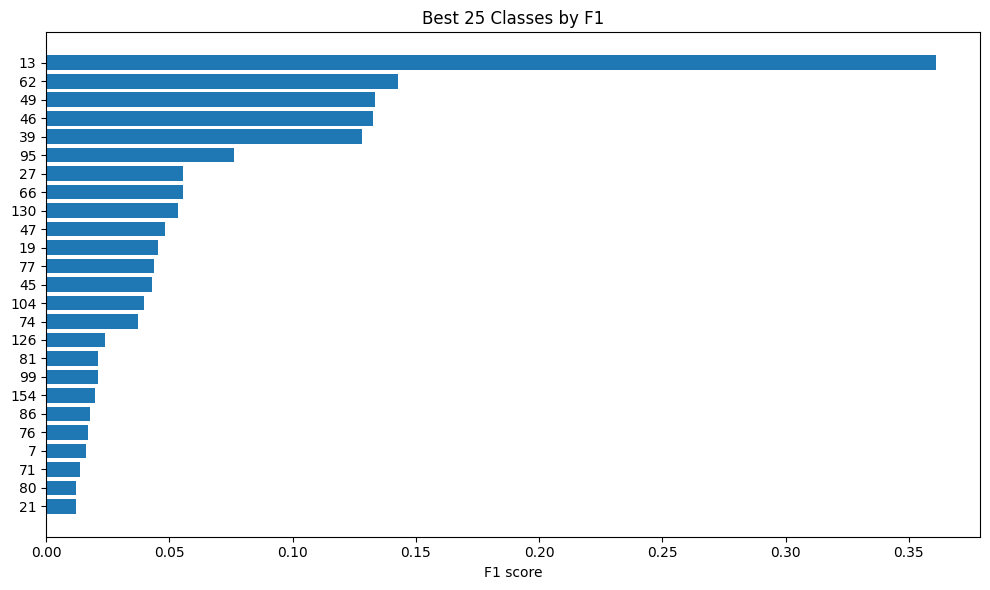

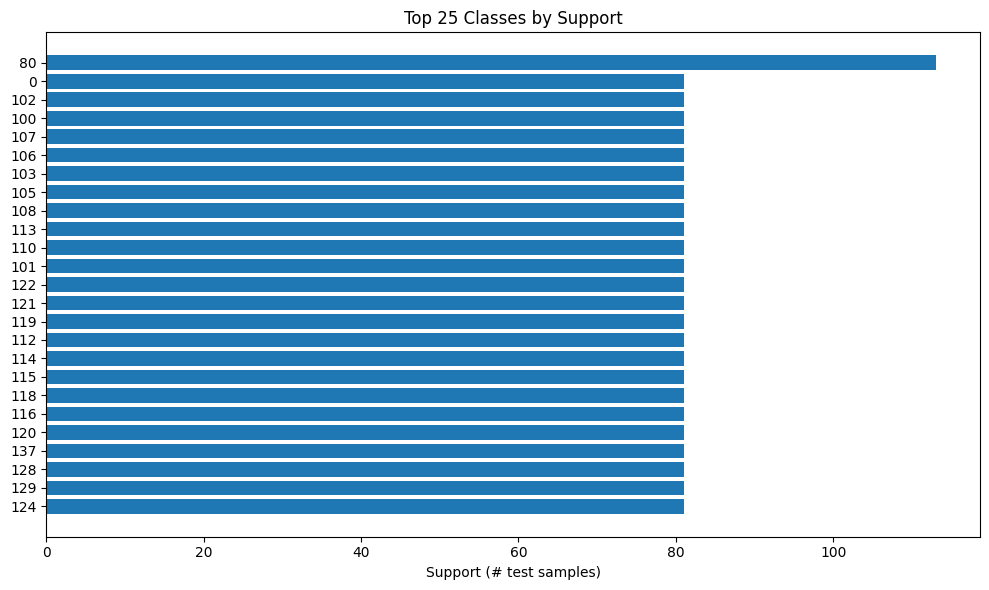

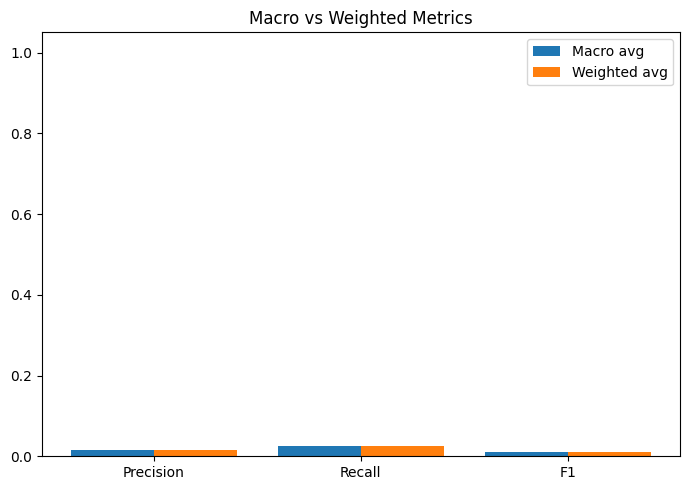

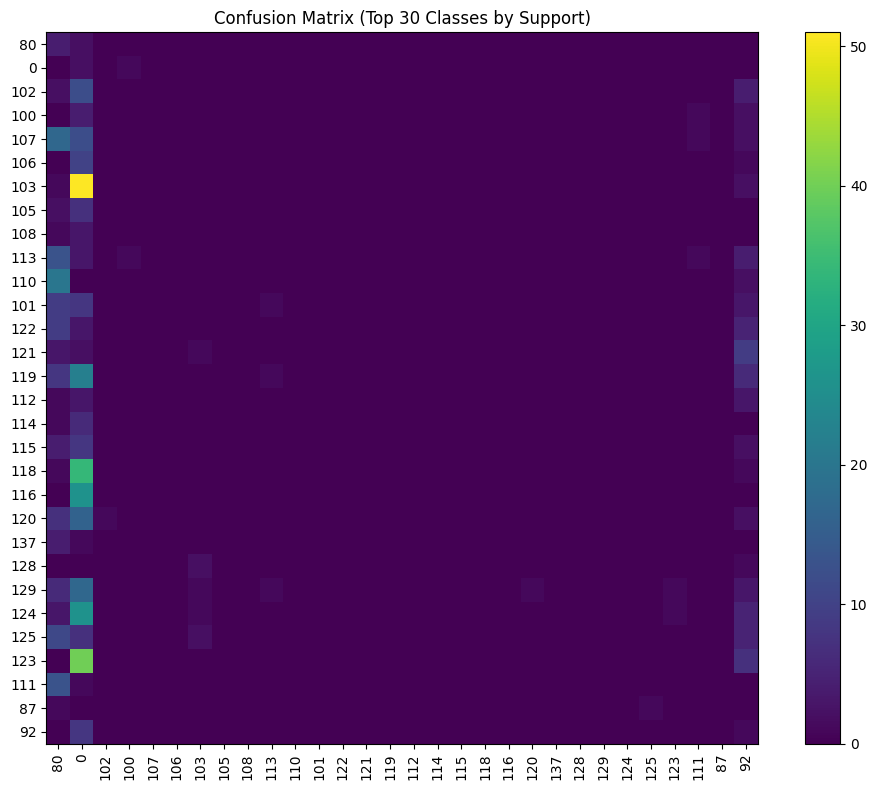

from matplotlib import pyplot as plt
_df_0['prec'].plot(kind='hist', bins=20, title='prec')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['rec'].plot(kind='hist', bins=20, title='rec')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['f1'].plot(kind='hist', bins=20, title='f1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['support'].plot(kind='hist', bins=20, title='support')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='prec', y='rec', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='f1', y='support', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['prec'].plot(kind='line', figsize=(8, 4), title='prec')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['rec'].plot(kind='line', figsize=(8, 4), title='rec')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['f1'].plot(kind='line', figsize=(8, 4), title='f1')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['support'].plot(kind='line', figsize=(8, 4), title='support')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support
)

# ----------------------------
# 1) Basic metrics + report df
# ----------------------------
acc = accuracy_score(all_y, all_preds)
print("✅ Test Accuracy:", acc)

report_dict = classification_report(
    all_y, all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# per-class rows only (remove avg/accuracy rows)
per_class = {k:v for k,v in report_dict.items() if k not in ["accuracy","macro avg","weighted avg"]}
df = pd.DataFrame(per_class).T
df["support"] = df["support"].astype(int)
df = df.rename(columns={"precision":"prec", "recall":"rec", "f1-score":"f1"})

display(df.head())
print("\nMacro avg:", report_dict["macro avg"])
print("Weighted avg:", report_dict["weighted avg"])

# ----------------------------
# 2) Graph: Worst classes by F1 (Top K)
# ----------------------------
K = 25  # change as you want
worst = df.sort_values("f1").head(K)

plt.figure(figsize=(10,6))
plt.barh(worst.index, worst["f1"])
plt.xlabel("F1 score")
plt.title(f"Worst {K} Classes by F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------
# 3) Graph: Best classes by F1 (Top K)
# ----------------------------
best = df.sort_values("f1", ascending=False).head(K)

plt.figure(figsize=(10,6))
plt.barh(best.index, best["f1"])
plt.xlabel("F1 score")
plt.title(f"Best {K} Classes by F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------
# 4) Graph: Support distribution (Top K by support)
# ----------------------------
top_support = df.sort_values("support", ascending=False).head(K)

plt.figure(figsize=(10,6))
plt.barh(top_support.index, top_support["support"])
plt.xlabel("Support (# test samples)")
plt.title(f"Top {K} Classes by Support")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------------------------
# 5) Graph: Macro vs Weighted metrics
# ----------------------------
macro = report_dict["macro avg"]
weighted = report_dict["weighted avg"]

metric_names = ["precision","recall","f1-score"]
macro_vals = [macro[m] for m in metric_names]
weighted_vals = [weighted[m] for m in metric_names]

x = np.arange(len(metric_names))

plt.figure(figsize=(7,5))
plt.bar(x - 0.2, macro_vals, width=0.4, label="Macro avg")
plt.bar(x + 0.2, weighted_vals, width=0.4, label="Weighted avg")
plt.xticks(x, ["Precision","Recall","F1"])
plt.ylim(0, 1.05)
plt.title("Macro vs Weighted Metrics")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 6) Confusion matrix (optional)
# For 156 classes, it's heavy & hard to read.
# We'll show for top N classes by support (subset).
# ----------------------------
N = 30  # choose 20-40 to keep readable
topN_names = df.sort_values("support", ascending=False).head(N).index.tolist()
name_to_idx = {name:i for i,name in enumerate(class_names)}
topN_idx = [name_to_idx[nm] for nm in topN_names]

# filter y/preds to only topN classes
mask = np.isin(all_y, topN_idx) & np.isin(all_preds, topN_idx)
y_sub = np.array(all_y)[mask]
p_sub = np.array(all_preds)[mask]

cm = confusion_matrix(y_sub, p_sub, labels=topN_idx)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (Top {N} Classes by Support)")
plt.colorbar()
plt.xticks(np.arange(N), topN_names, rotation=90)
plt.yticks(np.arange(N), topN_names)
plt.tight_layout()
plt.show()